# W&T Sales Associate Evaluation — Metric Design (profit basis)

Designs and validates a W&T-adapted version of the Coreline evaluation on 2 years
of item-level data. The eventual app imports the `compute_wandt()` function defined
here (see `wandt_app_spec.md`).

### Scope — the 5 **sales reps** only
The roster `Role` column distinguishes salespeople from managers. We score only the
**5 sales reps** — An Cao & Vanessa Wu (full-time), Garmi Mei, Ting Ting, Wendy Ye
(part-time) — and **drop managers (Cindy Chan, Morgan Wu, Tina Ni), inactive
(MT/PJ), and N/A** entirely. Accounts, baselines, work-shares, market drift, and
scores are all computed on the 5 reps' transactions only.

### Metric — **profit dollars**, judged **vs the market**
- Pay measure = **profit = `Extended Price − Extended Cost`** (cost is 100%
  populated). Within a day the margin is uniform across reps (so no rep gets a
  margin edge — it stays fair), but margin swings day-to-day (±~4.6pp), so raw
  revenue would misstate value. **No margin floor** — reps don't set margin.
- A floor-wide margin change is set by management, not the rep. It hits every
  account, so it cancels in **market drift**. The **headline is market-adjusted
  profit** (profit vs own baseline ÷ market drift); raw margin-regime changes wash
  out. The **real (volume) growth** number is shown beside it so volume-vs-price
  (inflation) is visible. Price-elasticity modeling is a documented future
  enhancement — handled here by market-adjustment + the volume diagnostic + manager
  judgment.

### Baseline ladder by **history length** (not "no year-ago = new")
- **New** = first order < ~13 weeks ago → feeds acquisition.
- **Provisional / ramping** = ≥13 weeks of history but no clean year-ago window →
  baseline = its **own prior quarter**.
- **Mature** = ≥1 year of history → **year-over-year** baseline.

### ⚠️ Weekend-direction caveat
The spec docx says weekends sell *higher*; the data shows the **opposite** (Sun/Sat
≈ 0.4%/2.8% of a week vs ~17–22% per weekday). The calendar normalization is needed
either way; flagged for confirmation.

## 1. Imports & tunable dials

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.tseries.holiday import USFederalHolidayCalendar

pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

ROSTER_PATH = "w&t_sales_associate_roster.xlsx"
SALES_FILES = {
    "FY24-25": "sales_data/June 2024- June 2025.XLSX",
    "FY25-26": "sales_data/June 2025-June 2026.XLSX",
}
SALES_ROLES = {"full time sales", "part time sales"}   # roles that get scored (managers excluded)

# Tunable metric dials (the eventual app stores these in settings).
DIALS = dict(
    window_weeks=13,             # trailing measurement window ("last 3 months")
    provisional_min_weeks=13,    # history before an account leaves 'new' for a prior-quarter baseline
    defend_pct=0.35,             # share of the fixed bonus pool to Defend; rest to Grow (Grow-heavy)
    acquisition_pct=0.02,        # acquisition ramp bonus = this % of a new account's profit
    acquisition_ramp_periods=3,  # a new account earns the ramp bonus for ~1 quarter, then graduates
    bonus_pool=1000.0,           # fixed Defend+Grow pool per period ($); acquisition is paid separately
    familiar_min_weeks=4,        # 'experienced' on an account if handled it >= this many distinct weeks last year
    familiar_max_gap_weeks=26,   # ...AND last touch within this many weeks (else 新接手 / ramping)
    holiday_weight=0.0,          # selling capacity assigned to a federal holiday (0 = a dead day)
)

## 2. Roster → identify the 5 sales reps

Attribution: `Batch Number[:2]` → roster `Batch Initial`, with free-text variants
(`MORGANW`, `TINAN`, `VANESSAW`) matched via `Other Names`. We then keep only reps
whose `Role` is a sales role and `Status` is Active.

In [2]:
roster = pd.read_excel(ROSTER_PATH)
roster["Batch Initial"] = roster["Batch Initial"].astype(str).str.strip().str.upper()
roster["Other Names"] = roster["Other Names"].astype(str).str.strip().str.upper()
roster.loc[roster["Other Names"].isin(["", "NAN"]), "Other Names"] = np.nan
roster["Sales Person Name"] = roster["Sales Person Name"].astype(str).str.strip()
roster.loc[roster["Sales Person Name"].isin(["", "nan"]), "Sales Person Name"] = np.nan
roster["Status"] = roster["Status"].astype(str).str.strip().str.title()
roster["Role"] = roster["Role"].astype(str).str.strip().str.lower()
roster = roster[roster["Status"].isin(["Active", "Inactive"])]   # drop the trailing junk row

sales_associates = sorted(roster.loc[(roster.Status == "Active") & (roster.Role.isin(SALES_ROLES)),
                                     "Sales Person Name"].dropna())
managers = sorted(roster.loc[roster.Role == "manager", "Sales Person Name"].dropna())

batch_prefix_to_person = {row["Batch Initial"]: row["Sales Person Name"] for _, row in roster.iterrows()}
variant_to_person = {row["Other Names"]: row["Sales Person Name"]
                     for _, row in roster.iterrows() if pd.notna(row["Other Names"])}


def resolve_associate(batch_number):
    """Resolve a batch string to a person: full Other-Names variant, else first-2-char prefix."""
    text = str(batch_number).strip().upper()
    if text in variant_to_person:
        return variant_to_person[text]
    return batch_prefix_to_person.get(text[:2], "Unmatched/Other")

print("scored sales reps:", sales_associates)
print("excluded managers:", managers)

scored sales reps: ['An Cao', 'Garmi Mei', 'Ting Ting', 'Vanessa Wu', 'Wendy Ye']
excluded managers: ['Cindy Chan', 'Morgan Wu', 'Tina Ni']


## 3. Load item-level sales, keep only the reps' transactions

Invoices only (returns ignored). We compute `line_profit` per line and restrict the
working frame to the 5 reps — so managers / inactive / N/A never enter any baseline,
share, or market figure.

In [3]:
raw = pd.concat([pd.read_excel(path).assign(**{"Fiscal Year": fy}) for fy, path in SALES_FILES.items()],
                ignore_index=True)
sales = raw[raw["SOP Type"] == "Invoice"].copy()
for column in ["Extended Price", "Extended Cost", "QTY"]:
    sales[column] = pd.to_numeric(sales[column], errors="coerce")
sales["Document Date"] = pd.to_datetime(sales["Document Date"])
sales["line_profit"] = sales["Extended Price"] - sales["Extended Cost"]
sales["associate"] = sales["Batch Number"].apply(resolve_associate)
sales["account"] = sales["Customer Number"].astype(str).str.strip()
sales["customer_name"] = sales["Customer Name"].astype(str).str.strip()

rep_sales = sales[sales["associate"].isin(sales_associates)].copy()
account_to_customer_name = rep_sales.drop_duplicates("account").set_index("account")["customer_name"]

print(f"all invoice rows {len(sales):,}  ->  rep-only rows {len(rep_sales):,}")
print(f"accounts {rep_sales['account'].nunique()}  |  total profit ${rep_sales['line_profit'].sum():,.0f}")

all invoice rows 123,429  ->  rep-only rows 102,493
accounts 258  |  total profit $7,337,911


## 4. Limited-stock exclusion (mechanism built, not applied to headline numbers)

Stockouts are per-date, so going forward the **manager supplies the constrained
items each period**. `exclude_constrained_items()` is applied to each window the
engine builds, so the **same items drop from both the current and baseline windows**
(apples-to-apples). `detect_constrained_candidates()` only *proposes* likely items
for the manager to confirm.

In [4]:
def exclude_constrained_items(df, constrained_item_numbers):
    """Drop the given Item Numbers. The engine calls this on each window → symmetric removal."""
    if not constrained_item_numbers:
        return df
    return df[~df["Item Number"].isin(set(constrained_item_numbers))]


def detect_constrained_candidates(df, top=8):
    """Propose limited-stock candidates: high revenue share + volatile monthly quantity."""
    summary = df.groupby("Item Description").agg(revenue=("Extended Price", "sum"), qty=("QTY", "sum"))
    summary["revenue_share"] = summary.revenue / summary.revenue.sum()
    monthly_qty = (df.assign(month=df["Document Date"].dt.to_period("M"))
                     .groupby(["Item Description", "month"])["QTY"].sum())
    summary["qty_volatility"] = (monthly_qty.groupby(level=0).std()
                                 / monthly_qty.groupby(level=0).mean().replace(0, np.nan)).reindex(summary.index)
    return summary.sort_values("revenue", ascending=False).head(top)

print("Auto-detected candidate constrained items (manager confirms — NOT auto-excluded):")
detect_constrained_candidates(rep_sales)[["revenue", "revenue_share", "qty_volatility"]]

Auto-detected candidate constrained items (manager confirms — NOT auto-excluded):


,revenue,revenue_share,qty_volatility
Item Description,,,
MANILA CLAM/REGULAR (25 LB/CASE) ¤¤ªá¸Ã (XO),"8,318,220.38",0.20,0.27
PACIFIC OYSTER MEAT - 16 OZ MEDIUM Ä®¦×,"1,246,000.50",0.03,0.35
20/30 CHAMPMAR H/O 6X4LB (ECUADOR),"1,221,669.85",0.03,0.33
8/12 BLACK TIGER SHRIMP/GOLDEN HILL H/L 6X4LB (INDONESIA),"966,421.20",0.02,0.57
STRIPED PANGASIUS MAWS .30 (40X12OZ) óÎ³½¨{ (VIETNAM),"930,303.00",0.02,0.40
16/20 TROPICAL H/L 10X4LB (ECUADOR),"830,340.80",0.02,0.37
30/40 CHAMPMAR H/O 6X4LB (ECUADOR),"809,773.60",0.02,0.59
600/800 GOLDEN POMPANO BULKED PACKED 1X40LB ª÷ÄI (CHINA),"760,793.50",0.02,0.69


## 5. Calendar normalization

Revenue per calendar day swings ~50× by weekday, so a window's total depends on
*which* days it contains. Two stacked fixes:

**(A) Whole-week alignment.** Windows are whole weeks; the baseline is exactly 52
weeks (364 days) back → identical weekday composition by construction.

**(B) Selling-day-equivalents.** Each weekday gets weight `f_d` = its share of a
normal week's revenue (`Σ f_d = 1`). A window's **capacity** = `Σ f_{dow(day)}`,
federal holidays down-weighted. The baseline is scaled by
`capacity_recent / capacity_baseline`, so holiday-placement differences cancel.

**Holiday pull-forward (block-level, event-anchored).** A holiday shifts demand to
adjacent days and its weekday drifts year to year; since pull-forward conserves the
weekly total, holiday weeks are compared as a block anchored to the holiday event
(Christmas demo below).

In [5]:
def day_of_week_weights(df):
    """Each weekday's share of a normal week's revenue (sums to 1). Index 0=Mon..6=Sun."""
    daily_revenue = df.groupby(df["Document Date"].dt.normalize())["Extended Price"].sum()
    by_day = pd.DataFrame({"revenue": daily_revenue.values, "day_of_week": daily_revenue.index.dayofweek})
    mean_per_day = by_day.groupby("day_of_week")["revenue"].mean()
    return (mean_per_day / mean_per_day.sum()).reindex(range(7)).fillna(0.0)

dow_weight = day_of_week_weights(rep_sales)
federal_holidays = set(USFederalHolidayCalendar().holidays(start="2023-01-01", end="2027-01-01").normalize())


def selling_day_capacity(start_date, end_date, holiday_weight=DIALS["holiday_weight"]):
    """Selling-day-equivalents in [start_date, end_date] (holidays down-weighted)."""
    days = pd.date_range(start_date, end_date, freq="D")
    return float(np.sum([(holiday_weight if day.normalize() in federal_holidays else 1.0) * dow_weight[day.dayofweek]
                         for day in days]))


def whole_week_window(df, window_end, weeks):
    window_start = window_end - pd.Timedelta(weeks=weeks)
    return df[(df["Document Date"] > window_start) & (df["Document Date"] <= window_end)]

weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("Day-of-week revenue weights (share of a normal week):")
print(pd.Series(dow_weight.values, index=weekday_labels).round(4).to_string())

Day-of-week revenue weights (share of a normal week):
Mon   0.20
Tue   0.14
Wed   0.23
Thu   0.18
Fri   0.23
Sat   0.01
Sun   0.00


In [6]:
# Holiday pull-forward demo: Christmas drifts weekday year to year (2024 Wed → 2025 Thu).
# Per-day matching mis-attributes the shift; an event-anchored BLOCK total is stable.
def holiday_block_total(df, holiday_date, days_each_side=3):
    low = holiday_date - pd.Timedelta(days=days_each_side)
    high = holiday_date + pd.Timedelta(days=days_each_side)
    return df[(df["Document Date"] >= low) & (df["Document Date"] <= high)]["Extended Price"].sum()

for year in (2024, 2025):
    christmas = pd.Timestamp(year, 12, 25)
    print(f"Christmas {year} ({christmas.day_name()}): ±3-day block revenue = "
          f"${holiday_block_total(rep_sales, christmas):,.0f}")

Christmas 2024 (Wednesday): ±3-day block revenue = $393,733
Christmas 2025 (Thursday): ±3-day block revenue = $569,142


## 6. Price-volume-mix (PVM) bridge — the real-growth signal

Splits each account's spend change between two periods into a **quantity** part and
a **price** part. For each item the account bought:
- `volume_dollars = (qty_recent − qty_baseline) × baseline_price`  → dollars from
  buying more/less at the old price.
- `price_dollars  = qty_recent × (price_recent − price_baseline)`  → dollars from
  the price moving on what they bought now.

The two sum exactly to the item's revenue change (and reconcile per account). New
items count fully as volume; dropped items as negative volume. It is done in
**dollars** because items use different units (lb, dozen, case). **`volume_dollars`
is the margin-neutral REAL growth** used beside the headline — it isolates real
demand from price/inflation.

In [7]:
def price_volume_mix_bridge(recent, baseline, baseline_scale):
    """Per-account volume$ / price$ bridge. baseline scaled by capacity_recent/capacity_baseline."""
    def by_item(df):
        grouped = df.groupby(["account", "Item Number"]).agg(qty=("QTY", "sum"),
                                                             revenue=("Extended Price", "sum"))
        grouped["unit_price"] = grouped["revenue"] / grouped["qty"].replace(0, np.nan)
        return grouped
    merged = by_item(recent).join(by_item(baseline), how="outer",
                                  lsuffix="_recent", rsuffix="_baseline").fillna(0.0)
    merged["qty_baseline"] *= baseline_scale
    merged["revenue_baseline"] *= baseline_scale
    baseline_price = merged["unit_price_baseline"].where(merged["unit_price_baseline"] > 0,
                                                         merged["unit_price_recent"])
    merged["volume_dollars"] = (merged["qty_recent"] - merged["qty_baseline"]) * baseline_price
    merged["price_dollars"] = np.where(merged["unit_price_baseline"] > 0,
                                       merged["qty_recent"] * (merged["unit_price_recent"] - merged["unit_price_baseline"]),
                                       0.0)
    return merged.groupby("account").agg(volume_dollars=("volume_dollars", "sum"),
                                         price_dollars=("price_dollars", "sum"),
                                         revenue_recent=("revenue_recent", "sum"),
                                         revenue_baseline=("revenue_baseline", "sum"))

_as_of = rep_sales["Document Date"].max().normalize()
_recent = whole_week_window(rep_sales, _as_of, 13)
_baseline = whole_week_window(rep_sales, _as_of - pd.Timedelta(weeks=52), 13)
_scale = (selling_day_capacity(_as_of - pd.Timedelta(weeks=13) + pd.Timedelta(days=1), _as_of)
          / selling_day_capacity(_as_of - pd.Timedelta(weeks=65) + pd.Timedelta(days=1), _as_of - pd.Timedelta(weeks=52)))
_bridge = price_volume_mix_bridge(_recent, _baseline, _scale)
print("PVM reconstruction max residual $%.6f (should be ~0)"
      % (_bridge.volume_dollars + _bridge.price_dollars
         - (_bridge.revenue_recent - _bridge.revenue_baseline)).abs().max())

PVM reconstruction max residual $0.000000 (should be ~0)


## 7–8. The engine `compute_wandt()` — baseline ladder, size de-trend, market drift

**Baseline ladder** (by history length): `new` (< ~1 quarter of history → feeds
acquisition) / `provisional` (has history but no year-ago → own prior quarter) /
`mature` (≥1 year → year-over-year).

**Size de-trend (decile).** Sort accounts by baseline size into 10 groups; each
group has a *typical* move (median recent/baseline). Big accounts naturally revert
down, small ones grow. We scale each target by its group's move **relative to the
overall market** (`decile median ÷ overall median`) — so it captures only the size
effect and does **not** double-count the common market move.

**Market drift.** The overall median of recent/baseline — how the whole book moved.
The **headline `profit_vs_market_pct`** divides each rep's performance by it, so a
floor-wide margin change (management's call) or a market-wide dip neither helps nor
hurts — only beating/lagging the market does.

**Work-share.** `share = rep profit on account ÷ account's total profit`;
`profit_target = share × baseline_profit × size_factor`. Coverage self-weights.

In [8]:
def classify_account_tier(history_weeks, has_year_ago_profit, has_prior_quarter_profit,
                          provisional_min_weeks=13):
    if history_weeks < provisional_min_weeks:
        return "new"                       # genuinely new → acquisition
    if has_year_ago_profit:
        return "mature"                    # ≥1yr history with a year-ago window → YoY
    if has_prior_quarter_profit:
        return "provisional"               # history but no clean year-ago → prior quarter
    return "new"                            # long-dormant reactivation, no comparable baseline


def compute_wandt(df, as_of, sales_team, *, window_weeks=13, provisional_min_weeks=13,
                  defend_pct=0.35, acquisition_pct=0.02, acquisition_ramp_periods=3,
                  bonus_pool=1000.0, constrained_item_numbers=None,
                  familiar_min_weeks=4, familiar_max_gap_weeks=26, exempt_accounts=None):
    as_of = pd.Timestamp(as_of).normalize()
    exempt_accounts = set(exempt_accounts or [])
    df = exclude_constrained_items(df, constrained_item_numbers)

    recent = whole_week_window(df, as_of, window_weeks)
    year_ago = whole_week_window(df, as_of - pd.Timedelta(weeks=52), window_weeks)
    prior_quarter = whole_week_window(df, as_of - pd.Timedelta(weeks=window_weeks), window_weeks)
    capacity_recent = selling_day_capacity(as_of - pd.Timedelta(weeks=window_weeks) + pd.Timedelta(days=1), as_of)
    capacity_year_ago = selling_day_capacity(as_of - pd.Timedelta(weeks=52 + window_weeks) + pd.Timedelta(days=1),
                                             as_of - pd.Timedelta(weeks=52))
    capacity_prior_quarter = selling_day_capacity(as_of - pd.Timedelta(weeks=2 * window_weeks) + pd.Timedelta(days=1),
                                                  as_of - pd.Timedelta(weeks=window_weeks))
    scale_year_ago = capacity_recent / capacity_year_ago if capacity_year_ago else 1.0
    scale_prior_quarter = capacity_recent / capacity_prior_quarter if capacity_prior_quarter else 1.0

    account = pd.DataFrame({
        "recent_profit": recent.groupby("account")["line_profit"].sum(),
        "recent_revenue": recent.groupby("account")["Extended Price"].sum(),
        "year_ago_profit": year_ago.groupby("account")["line_profit"].sum() * scale_year_ago,
        "year_ago_revenue": year_ago.groupby("account")["Extended Price"].sum() * scale_year_ago,
        "prior_quarter_profit": prior_quarter.groupby("account")["line_profit"].sum() * scale_prior_quarter,
        "prior_quarter_revenue": prior_quarter.groupby("account")["Extended Price"].sum() * scale_prior_quarter,
    }).fillna(0.0)
    first_seen = df.groupby("account")["Document Date"].min()
    account["history_weeks"] = (as_of - first_seen.reindex(account.index)).dt.days / 7

    account["tier"] = [classify_account_tier(history_weeks, year_ago_profit > 0, prior_quarter_profit > 0,
                                             provisional_min_weeks)
                       for history_weeks, year_ago_profit, prior_quarter_profit
                       in zip(account.history_weeks, account.year_ago_profit, account.prior_quarter_profit)]
    account["baseline_profit"] = np.where(account.tier == "mature", account.year_ago_profit,
                                 np.where(account.tier == "provisional", account.prior_quarter_profit, 0.0))
    account["baseline_revenue"] = np.where(account.tier == "mature", account.year_ago_revenue,
                                  np.where(account.tier == "provisional", account.prior_quarter_revenue, 0.0))

    # size de-trend (relative to market) + market drift, both on profit
    scored_accounts = account[(account.baseline_profit > 50) & (account.recent_profit != 0)].copy()
    if len(scored_accounts) >= 10:
        scored_accounts["ratio"] = scored_accounts.recent_profit / scored_accounts.baseline_profit
        decile = pd.qcut(scored_accounts.baseline_profit, 10, labels=False, duplicates="drop")
        decile_median_ratio = scored_accounts.groupby(decile)["ratio"].transform("median")
        market_drift = float(scored_accounts["ratio"].median())
        # relative size effect only → does not double-count the market move market_drift removes
        account["size_factor"] = (decile_median_ratio / market_drift).reindex(account.index).fillna(1.0)
    else:
        account["size_factor"] = 1.0
        market_drift = 1.0

    # familiarity in the year before the window → 新接手 / ramping flag
    window_start = as_of - pd.Timedelta(weeks=window_weeks)
    before_window = df[(df["Document Date"] <= window_start)
                       & (df["Document Date"] > window_start - pd.Timedelta(weeks=52))].copy()
    familiar_weeks, weeks_since_last_touch = {}, {}
    if len(before_window):
        before_window["iso_week"] = before_window["Document Date"].dt.to_period("W")
        familiarity = before_window.groupby(["associate", "account"]).agg(
            weeks=("iso_week", "nunique"), last_touch=("Document Date", "max"))
        familiar_weeks = familiarity["weeks"].to_dict()
        weeks_since_last_touch = ((window_start - familiarity["last_touch"]).dt.days / 7).to_dict()

    volume_bridge = price_volume_mix_bridge(recent, year_ago, scale_year_ago)

    # per (associate, account) lines — credit each rep their own profit
    line_records = []
    recent_team = recent[recent["associate"].isin(sales_team)]
    for (associate, account_id), group in recent_team.groupby(["associate", "account"]):
        if account_id in exempt_accounts:
            continue
        account_row = account.loc[account_id] if account_id in account.index else None
        actual_profit = group["line_profit"].sum()
        tier = account_row["tier"] if account_row is not None else "new"
        has_baseline = account_row is not None and account_row["baseline_profit"] > 0
        work_share = (actual_profit / account_row["recent_profit"]) if (account_row is not None and account_row["recent_profit"]) else np.nan
        size_factor = account_row["size_factor"] if account_row is not None else 1.0
        profit_target = work_share * account_row["baseline_profit"] * size_factor if has_baseline else np.nan
        if not has_baseline:
            status = "new"
        else:
            is_familiar = (familiar_weeks.get((associate, account_id), 0) >= familiar_min_weeks
                           and weeks_since_last_touch.get((associate, account_id), 1e9) <= familiar_max_gap_weeks)
            status = "scored" if is_familiar else "ramping"
        volume_dollars = volume_bridge.loc[account_id, "volume_dollars"] * work_share if account_id in volume_bridge.index else 0.0
        baseline_revenue_share = (account_row["baseline_revenue"] * work_share) if account_row is not None else 0.0
        line_records.append(dict(associate=associate, account=account_id, tier=tier, status=status,
                                 actual_profit=actual_profit, profit_target=profit_target, work_share=work_share,
                                 volume_dollars=volume_dollars, baseline_revenue_share=baseline_revenue_share))
    lines = pd.DataFrame(line_records)

    # acquisition ramp bonus (forward-looking; commission-style on new-account profit)
    new_account_rollup = (lines[lines.status == "new"].groupby("associate")
                          .agg(new_accounts=("account", "nunique"), new_account_profit=("actual_profit", "sum")))
    new_account_rollup["acquisition_bonus"] = new_account_rollup["new_account_profit"] * acquisition_pct

    scorecard_rows = []
    for associate in sales_team:
        scored = lines[(lines.associate == associate) & (lines.status.isin(["scored", "ramping"]))]
        actual_profit = scored.actual_profit.sum()
        profit_target = scored.profit_target.sum()
        baseline_revenue = scored.baseline_revenue_share.sum()
        fully_scored = scored[scored.status == "scored"]
        grow_dollars = (max(0.0, fully_scored.actual_profit.sum() - fully_scored.profit_target.sum())
                        + scored[scored.status == "ramping"]["volume_dollars"].clip(lower=0).sum())
        acquisition = new_account_rollup.loc[associate] if associate in new_account_rollup.index else None
        scorecard_rows.append(dict(
            associate=associate, accounts=int(scored.account.nunique()),
            actual_profit=actual_profit, profit_target=profit_target,
            profit_perf_pct=(actual_profit / profit_target - 1) * 100 if profit_target else None,
            profit_vs_market_pct=((actual_profit / profit_target) / market_drift - 1) * 100 if (profit_target and market_drift) else None,
            real_growth_pct=(scored.volume_dollars.sum() / baseline_revenue * 100) if baseline_revenue else None,
            defend_dollars=actual_profit, grow_dollars=grow_dollars,
            new_accounts=int(acquisition.new_accounts) if acquisition is not None else 0,
            acquisition_bonus=float(acquisition.acquisition_bonus) if acquisition is not None else 0.0))
    scorecards = pd.DataFrame(scorecard_rows)

    # Grow-heavy fixed-pool split; acquisition paid separately (commission-style)
    defend_pool, grow_pool = bonus_pool * defend_pct, bonus_pool * (1 - defend_pct)
    total_defend = scorecards.defend_dollars.clip(lower=0).sum()
    total_grow = scorecards.grow_dollars.clip(lower=0).sum()
    scorecards["defend_bonus"] = defend_pool * scorecards.defend_dollars.clip(lower=0) / total_defend if total_defend else 0.0
    scorecards["grow_bonus"] = grow_pool * scorecards.grow_dollars.clip(lower=0) / total_grow if total_grow else 0.0
    scorecards["total_bonus"] = scorecards.defend_bonus + scorecards.grow_bonus + scorecards.acquisition_bonus
    return dict(as_of=as_of, market_drift=market_drift, account=account, lines=lines, scorecards=scorecards,
                capacity_recent=capacity_recent, capacity_year_ago=capacity_year_ago)

## 9. Per-rep scorecards (latest period)

**Headline = `profit_vs_market_pct`** (margin-regime-neutral). **`real_growth_pct`**
(volume) shown beside it for the inflation lens.

In [9]:
as_of = rep_sales["Document Date"].max().normalize()
result = compute_wandt(rep_sales, as_of, sales_associates, **{key: DIALS[key] for key in
    ["window_weeks", "provisional_min_weeks", "defend_pct", "acquisition_pct",
     "acquisition_ramp_periods", "bonus_pool", "familiar_min_weeks", "familiar_max_gap_weeks"]})

print(f"as_of={result['as_of'].date()}  |  trailing {DIALS['window_weeks']} wks vs same 13 wks last year")
print(f"market drift = {result['market_drift']:.3f}  (the rep book moved this vs its baseline)")
print(f"account tiers: {result['account'].tier.value_counts().to_dict()}")
print(f"line statuses: {result['lines'].status.value_counts().to_dict()}\n")

scorecards = result["scorecards"].sort_values("profit_vs_market_pct", ascending=False)
scorecards[["associate", "accounts", "actual_profit", "profit_target", "profit_vs_market_pct",
            "real_growth_pct", "new_accounts", "defend_bonus", "grow_bonus",
            "acquisition_bonus", "total_bonus"]]

as_of=2026-06-22  |  trailing 13 wks vs same 13 wks last year
market drift = 0.945  (the rep book moved this vs its baseline)
account tiers: {'mature': 202, 'provisional': 28, 'new': 10}
line statuses: {'scored': 303, 'ramping': 78, 'new': 12}



,associate,accounts,actual_profit,profit_target,profit_vs_market_pct,real_growth_pct,new_accounts,defend_bonus,grow_bonus,acquisition_bonus,total_bonus
3,Vanessa Wu,79,"196,026.88","184,492.53",12.46,7.01,5,70.85,419.99,54.44,545.29
1,Garmi Mei,110,"262,706.82","260,028.70",6.93,3.89,4,94.95,189.59,28.49,313.04
0,An Cao,69,"261,826.48","263,348.58",5.23,5.20,1,94.63,21.16,3.11,118.90
2,Ting Ting,79,"156,330.16","159,116.62",3.99,1.44,2,56.50,14.98,73.19,144.67
4,Wendy Ye,44,"91,461.26","101,650.59",-4.77,-3.45,0,33.06,4.28,0.00,37.33


## 10. New / ramping accounts per rep (customer name + profit)

In [10]:
new_and_ramping = result["lines"][result["lines"].status.isin(["new", "ramping"])].copy()
new_and_ramping["customer"] = new_and_ramping["account"].map(account_to_customer_name)
new_and_ramping["profit"] = new_and_ramping["actual_profit"].round(0)

for associate in sales_associates:
    rows = new_and_ramping[new_and_ramping.associate == associate].sort_values(["status", "profit"], ascending=[True, False])
    new_count = (rows.status == "new").sum()
    print(f"\n{associate}: {new_count} new, {(rows.status=='ramping').sum()} ramping")
    if len(rows):
        print(rows[["status", "customer", "profit"]].to_string(index=False))


An Cao: 1 new, 6 ramping
 status                                             customer  profit
    new                Walfood II Market ¸UµØ¶W¥«II ªk©Ô²±©±  155.00
ramping                              D&Z SUPERMARKET  ·s¤j²³  496.00
ramping                          LUCKY FAMILY GROCERY/µ½¤§®a  486.00
ramping            W&E SEAFOOD WHOLESALE LLC    ©ôªF®üÂA§åµo  327.00
ramping              HUNG VUONG FOOD MARKET- BERWYN «íµo¶W¥«  261.00
ramping                                  P. ZOLLO & SONS INC   58.00
ramping YEUNG'S TRADING CORP /é¾_x008d_æ˜Œæµ·é®®å…¬å_x008f_¸   46.00

Garmi Mei: 4 new, 28 ramping
 status                                             customer   profit
    new                                    PREMIUM FOODS USA 1,053.00
    new                     122 MEAT MARKET INC/¼w©÷(­ð¤Hµó)   238.00
    new                       THE BAY SHELLFISH & OYSTER BAR   111.00
    new                  W&K MARKET INC/¥î­p®üÂA®ü¨ý­¹«~¤½¥q    22.00
ramping                      ASIAN SUPERMA

## 11. Closure / silence detector (decision support)

A confirmed closed store is a **manager** action (→ Exempt, excluded from churn).
The system *surfaces* candidates: accounts silent far longer than their **own**
normal order cadence (some order daily, some monthly), for the manager to confirm.

In [11]:
def flag_silent_accounts(df, as_of, gap_multiple=3.0, min_orders=5):
    """Flag accounts whose silence exceeds gap_multiple × their own median inter-order gap."""
    records = []
    for account_id, group in df.groupby("account"):
        order_dates = pd.Series(sorted(group["Document Date"].dt.normalize().unique()))
        if len(order_dates) < min_orders:
            continue
        median_gap_days = order_dates.diff().dt.days.median()
        days_silent = (as_of - order_dates.iloc[-1]).days
        if median_gap_days and days_silent > gap_multiple * median_gap_days:
            records.append((account_id, account_to_customer_name.get(account_id),
                            round(median_gap_days, 1), days_silent))
    return pd.DataFrame(records, columns=["account", "customer", "median_gap_days", "days_silent"]) \
             .sort_values("days_silent", ascending=False)

silent_accounts = flag_silent_accounts(rep_sales, as_of)
print(f"closure candidates (silent > 3× own cadence): {len(silent_accounts)}")
silent_accounts.head(10)

closure candidates (silent > 3× own cadence): 43


,account,customer,median_gap_days,days_silent
17,FRESHQU03,FRESH FARM SUPERMARKET CORP,5.50,663
28,LANGQBK02,LANG QI FOODS SUPERMARKET/·s«íµo­¹«~¶W¥«,2.00,643
29,LONGHBK01,LONG HARBOR TRADING INC./ªø´ä­¹«~§åµo¤½¥q,7.00,543
10,CHUNGBK01,CHUNG SHUN HONG LLC/¤¤«H¦æ,3.00,452
16,FOODEQU01,FOOD EXPRESS SUPERMARKET/ ª÷«°¶W¥«(WOODSIDE),9.00,437
30,MACHBQU01,MACH BAZAR,14.00,389
5,BDFOOQU01,BD FOODS DISTRIBUTORS INC.,11.00,384
4,ASIANNJ06,ASIAN FOOD CNTR RT22/¬üªF(3),7.00,376
18,FRESHQU04,FRESH MART NY INC ÏÊ³¬ÊÐ,8.00,370
38,SUCHANBK01,SUCHANA SUPERMARKET INC,10.50,357


## 12. Visualizations

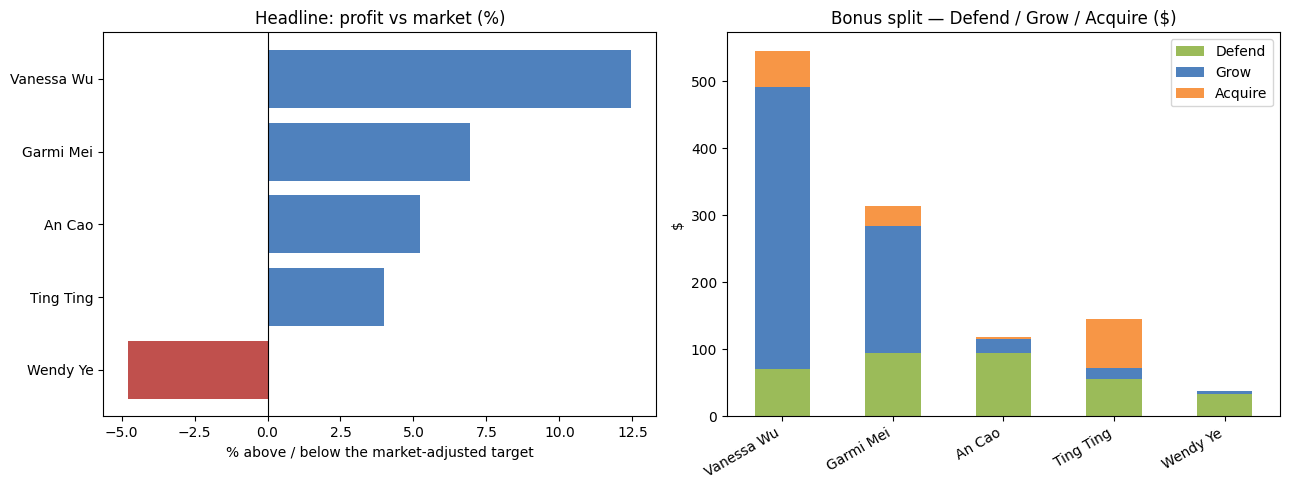

In [12]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5))

ranked = scorecards.sort_values("profit_vs_market_pct")
bar_colors = ["#c0504d" if value < 0 else "#4f81bd" for value in ranked.profit_vs_market_pct]
ax_left.barh(ranked.associate, ranked.profit_vs_market_pct, color=bar_colors)
ax_left.axvline(0, color="k", lw=0.8)
ax_left.set_title("Headline: profit vs market (%)")
ax_left.set_xlabel("% above / below the market-adjusted target")

bonus = scorecards.set_index("associate")[["defend_bonus", "grow_bonus", "acquisition_bonus"]]
bonus.plot(kind="bar", stacked=True, ax=ax_right,
           color={"defend_bonus": "#9bbb59", "grow_bonus": "#4f81bd", "acquisition_bonus": "#f79646"})
ax_right.set_title("Bonus split — Defend / Grow / Acquire ($)")
ax_right.set_xlabel(""); ax_right.set_ylabel("$"); ax_right.legend(["Defend", "Grow", "Acquire"])
plt.setp(ax_right.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); plt.show()

## 13. Sanity checks

In [13]:
# (a) PVM reconstructs the revenue change
bridge = price_volume_mix_bridge(whole_week_window(rep_sales, as_of, 13),
                                 whole_week_window(rep_sales, as_of - pd.Timedelta(weeks=52), 13),
                                 result["capacity_recent"] / result["capacity_year_ago"])
assert (bridge.volume_dollars + bridge.price_dollars
        - (bridge.revenue_recent - bridge.revenue_baseline)).abs().max() < 1e-6
print("✓ volume$ + price$ reconstructs revenue change")

# (b) market-adjusted profit is NEUTRAL to a uniform (floor-wide) margin cut
margin_cut = rep_sales.copy()
in_recent_window = margin_cut["Document Date"] > as_of - pd.Timedelta(weeks=13)
margin_cut.loc[in_recent_window, "line_profit"] *= 0.80
base_headline = compute_wandt(rep_sales, as_of, sales_associates)["scorecards"].set_index("associate")["profit_vs_market_pct"]
cut_headline = compute_wandt(margin_cut, as_of, sales_associates)["scorecards"].set_index("associate")["profit_vs_market_pct"]
max_drift = (base_headline - cut_headline).abs().max()
assert max_drift < 0.5, "market adjustment should neutralize a floor-wide margin change"
print(f"✓ headline unchanged under a uniform 20% margin cut (max move {max_drift:.4f} pp)")

# (c) scope = 5 reps only; ladder tiers all populated
assert set(result["scorecards"].associate) == set(sales_associates)
assert not set(result["lines"].associate) & set(managers)
assert (result["account"].tier.value_counts().reindex(["new", "provisional", "mature"]).fillna(0) > 0).all()
print("✓ 5 reps scored (no managers); new/provisional/mature tiers all populated")

# (d) constrained-item exclusion is symmetric (current AND baseline)
manila_items = sorted(rep_sales.loc[rep_sales["Item Description"].str.upper().str.contains("MANILA", na=False),
                                    "Item Number"].unique())
without_manila = exclude_constrained_items(rep_sales, manila_items)
for window_end in (as_of, as_of - pd.Timedelta(weeks=52)):
    assert not whole_week_window(without_manila, window_end, 13)["Item Number"].isin(manila_items).any()
print(f"✓ MANILA CLAM ({len(manila_items)} item#) removed from BOTH windows")
print("\nALL SANITY CHECKS PASSED")

✓ volume$ + price$ reconstructs revenue change


✓ headline unchanged under a uniform 20% margin cut (max move 0.0000 pp)
✓ 5 reps scored (no managers); new/provisional/mature tiers all populated
✓ MANILA CLAM (3 item#) removed from BOTH windows

ALL SANITY CHECKS PASSED


## 14. Findings & next steps

**Established**
- A reusable `compute_wandt()` engine on a **profit** basis, scoped to the **5 sales
  reps**, validated on 2 years of item-level data.
- **Headline = market-adjusted profit**, which neutralizes management-set margin
  changes (verified: 0pp move under a uniform margin cut), with **real (volume)
  growth** beside it for the inflation lens.
- A **corrected baseline ladder** by history length (new / provisional / mature).
- Calendar normalization, a reconciling PVM bridge, a continuous acquisition ramp,
  a Grow-heavy bonus split, per-rep new-account lists, and a closure/silence detector.

**Caveats**
- Weekend direction in the docx is inverted vs the data — please confirm.
- Limited-stock exclusion is **built but not applied** (needs the manager's
  per-period item list).
- Acquisition numbers are **illustrative** (forward-looking design); `acquisition_pct`
  is a commission-style dial.
- Customer names from the ERP carry some encoding noise in the non-English text
  (cosmetic; account IDs are exact).

**Next steps**
1. Confirm dials (`defend_pct`, `acquisition_pct`, ramp length, holiday weight).
2. Stand up per-period constrained-item entry + closure confirmation (manager).
3. Port `compute_wandt()` into the app engine per `wandt_app_spec.md`.
4. (Future) coarse category-level price-elasticity, if desired.